# Italian Real Estate Market — Integrated Market Dynamics

This notebook integrates the three analytical dimensions developed in the previous notebooks: **OMI quotations, transaction volumes (NTN) and population**.

The objective is to build a controlled municipality-year/semester analytical panel and investigate whether demographic dynamics are associated with changes in real-estate prices and transaction activity.

**Pipeline:** raw sources → controlled aggregation → key harmonisation → coverage checks → integrated panel → price/volume/demography analysis → interpretation limits.

> Important: association is not causality. The integrated panel is designed for descriptive and exploratory analysis, not causal inference.

## 1. Setup and source inventory

Each source is loaded independently. No notebook state is required from Notebooks 01–03, making this analysis reproducible from the repository data alone.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

QUOTATIONS_DIR = PROJECT_ROOT / 'data' / 'raw' / 'quotations'
TRANSACTIONS_DIR = PROJECT_ROOT / 'data' / 'raw' / 'transactions'
POPULATION_DIR = PROJECT_ROOT / 'data' / 'raw' / 'population'
for path in [QUOTATIONS_DIR, TRANSACTIONS_DIR, POPULATION_DIR]:
    assert path.exists(), f'Missing source directory: {path}'

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Project root:', PROJECT_ROOT)

Project root: c:\Users\cc1323\italian-real-estate-analysis


## 2. OMI quotation panel

OMI observations are aggregated to **municipality + semester**. For residential property, the municipality quotation is represented by the median of the quotation midpoint. This is a descriptive aggregation and is not an official OMI average price.

In [ ]:
quotation_files = sorted(QUOTATIONS_DIR.glob('omi_quotations_*.csv'))
if not quotation_files:
    raise FileNotFoundError('No OMI quotation files found.')

quotation_parts = []
for path in quotation_files:
    match = re.search(r'_(\d{4})_(S[12])$', path.stem)
    if not match:
        continue
    year = int(match.group(1))
    semester = match.group(2)
    df = pd.read_csv(path, sep=';', low_memory=False)
    df.columns = [str(c).replace('\ufeff', '').strip() for c in df.columns]
    required = ['Comune_ISTAT', 'Descr_Tipologia', 'Compr_min', 'Compr_max']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'{path.name}: missing columns {missing}')
    df['reference_year'] = year
    df['semester'] = semester
    quotation_parts.append(df[required + ['reference_year', 'semester']])

if not quotation_parts:
    raise ValueError('No valid OMI quotation files matched the expected year/semester pattern.')

omi = pd.concat(quotation_parts, ignore_index=True)
omi['municipality_code'] = omi['Comune_ISTAT'].astype('string').str.strip()
for column in ['Compr_min', 'Compr_max']:
    omi[column] = pd.to_numeric(omi[column], errors='coerce')
omi['Compr_mid'] = omi[['Compr_min', 'Compr_max']].mean(axis=1)
residential_mask = omi['Descr_Tipologia'].astype('string').str.contains('abitazion|villa', case=False, na=False)
residential_omi = omi.loc[residential_mask].copy()

quotation_panel = (
    residential_omi.dropna(subset=['municipality_code', 'Compr_mid'])
    .groupby(['reference_year', 'semester', 'municipality_code'], as_index=False)
    .agg(
        median_price_m2=('Compr_mid', 'median'),
        p25_price_m2=('Compr_mid', lambda x: x.quantile(0.25)),
        p75_price_m2=('Compr_mid', lambda x: x.quantile(0.75)),
        quotation_observations=('Compr_mid', 'size'),
    )
)
quotation_panel['reference_date'] = pd.to_datetime(
    quotation_panel['reference_year'].astype(str) + '-' +
    quotation_panel['semester'].map({'S1': '06-30', 'S2': '12-31'})
)
print(f'Integrated quotation observations: {len(quotation_panel):,}')
display(quotation_panel.head())

In [28]:
quotation_panel['municipality_code'] = (
    pd.to_numeric(
        quotation_panel['municipality_code'],
        errors='coerce'
    )
    .astype('Int64')
    .astype('string')
    .str[-6:]
)

quotation_panel = quotation_panel[
    quotation_panel['municipality_code'].notna()
    & quotation_panel['municipality_code'].ne('000000')
].copy()

In [32]:
display(
    quotation_panel[
        ['reference_year', 'municipality_code']
    ]
    .drop_duplicates()
    .head(20)
)

,reference_year,municipality_code
0,2004,0
1,2004,001001
2,2004,001002
3,2004,001003
4,2004,001004
5,2004,001005
6,2004,001006
7,2004,001007
8,2004,001008
9,2004,001009


## 3. Transaction panel

The transaction source is annual. We retain municipalities with a controlled one-row-per-municipality-year structure and identify the NTN field dynamically because source releases can differ in naming.

In [9]:
# ============================================================
# 3. TRANSACTION PANEL
# ============================================================

year_folders = sorted(
    p for p in TRANSACTIONS_DIR.iterdir()
    if p.is_dir() and p.name.isdigit()
)

transaction_parts = []
excluded_transaction_codes = []


def find_file(folder, token):
    matches = [
        p for p in folder.iterdir()
        if p.is_file() and token in p.name.lower()
    ]

    if len(matches) != 1:
        raise ValueError(
            f'{folder.name}: expected one {token} file, '
            f'found {len(matches)}'
        )

    return matches[0]


def clean_code(series):
    """
    Normalise municipality codes while preserving leading zeros.
    """
    return (
        series.astype('string')
        .str.strip()
        .str.upper()
        .str.replace(r'\.0$', '', regex=True)
    )


def valid_municipality_code(series):
    """
    Valid municipality codes in the source can be:
      - alphanumeric, e.g. A001, M438
      - numeric, if present in some source versions

    Excludes labels such as NON NATI / NON NATO.
    """
    return (
        series.str.fullmatch(
            r'(?:[A-Z]\d+|\d+)',
            na=False,
        )
    )


for folder in year_folders:

    year = int(folder.name)

    # --------------------------------------------------------
    # Load source files
    # --------------------------------------------------------

    lista_path = find_file(folder, 'lista-com')
    valori_path = find_file(folder, 'valori-res')

    lista = pd.read_csv(
        lista_path,
        sep=';',
        decimal=',',
        low_memory=False,
    )

    valori_res = pd.read_csv(
        valori_path,
        sep=';',
        decimal=',',
        low_memory=False,
    )

    # --------------------------------------------------------
    # Normalise column names
    # --------------------------------------------------------

    lista.columns = (
        lista.columns
        .astype(str)
        .str.strip()
    )

    valori_res.columns = (
        valori_res.columns
        .astype(str)
        .str.strip()
    )

    # --------------------------------------------------------
    # Identify municipality-code columns
    # --------------------------------------------------------

    lista_code_candidates = [
        c for c in lista.columns
        if 'codcom' in c.lower()
    ]

    valori_code_candidates = [
        c for c in valori_res.columns
        if 'codcom' in c.lower()
    ]

    if len(lista_code_candidates) != 1:
        raise KeyError(
            f'{year}: LISTA-COM municipality code column not '
            f'found unambiguously. '
            f'Candidates: {lista_code_candidates}'
        )

    if len(valori_code_candidates) != 1:
        raise KeyError(
            f'{year}: VALORI-RES municipality code column not '
            f'found unambiguously. '
            f'Candidates: {valori_code_candidates}'
        )

    lista_code_col = lista_code_candidates[0]
    valori_code_col = valori_code_candidates[0]

    # --------------------------------------------------------
    # Rename municipality-code columns
    # --------------------------------------------------------

    lista = lista.rename(
        columns={
            lista_code_col: 'municipality_code'
        }
    )

    valori_res = valori_res.rename(
        columns={
            valori_code_col: 'municipality_code'
        }
    )

    lista['municipality_code'] = clean_code(
        lista['municipality_code']
    )

    valori_res['municipality_code'] = clean_code(
        valori_res['municipality_code']
    )

    # --------------------------------------------------------
    # Identify total NTN column
    # --------------------------------------------------------

    ntn_columns = [
        c for c in valori_res.columns
        if re.search(
            r'\bNTN\b',
            c,
            flags=re.IGNORECASE,
        )
    ]

    total_candidates = []

    # Historical formats
    exact_patterns = [
        rf'^NTN\s*{year}$',
        rf'^NTN_{year}$',
        rf'^NTN\s*{year}\s*_?totale$',
        rf'^NTN_{year}_totale$',
        r'^NTN$',
    ]

    for pattern in exact_patterns:

        matches = [
            c for c in valori_res.columns
            if re.fullmatch(
                pattern,
                c.strip(),
                flags=re.IGNORECASE,
            )
        ]

        if matches:
            total_candidates.extend(matches)

    # --------------------------------------------------------
    # Fallback: identify total NTN among NTN columns
    # --------------------------------------------------------

    if not total_candidates:

        size_keywords = [
            'fino',
            '50 -',
            '50-|',
            '85 -',
            '85-|',
            '115 -',
            '115-|',
            'oltre',
        ]

        for col in ntn_columns:

            col_lower = col.lower()

            if any(
                keyword in col_lower
                for keyword in size_keywords
            ):
                continue

            total_candidates.append(col)

    total_candidates = list(
        dict.fromkeys(total_candidates)
    )

    if not total_candidates:
        raise KeyError(
            f'{year}: NTN total column not found. '
            f'Available NTN columns: {ntn_columns}'
        )

    if len(total_candidates) == 1:

        ntn_col = total_candidates[0]

    else:

        year_specific = [
            c for c in total_candidates
            if str(year) in c
        ]

        if len(year_specific) == 1:

            ntn_col = year_specific[0]

        else:

            raise ValueError(
                f'{year}: ambiguous NTN total columns: '
                f'{total_candidates}'
            )

    # --------------------------------------------------------
    # Keep municipality code + total NTN
    # --------------------------------------------------------

    values = valori_res[
        ['municipality_code', ntn_col]
    ].copy()

    values = values.rename(
        columns={
            ntn_col: 'ntn'
        }
    )

    values['ntn'] = pd.to_numeric(
        values['ntn'],
        errors='coerce',
    )

    # --------------------------------------------------------
    # Identify valid / excluded source codes
    # --------------------------------------------------------

    valid_values_mask = valid_municipality_code(
        values['municipality_code']
    )

    excluded = values.loc[
        ~valid_values_mask,
        ['municipality_code', 'ntn']
    ].copy()

    if not excluded.empty:

        excluded['year'] = year

        excluded_transaction_codes.append(
            excluded[
                ['year', 'municipality_code', 'ntn']
            ]
        )

    values = values.loc[
        valid_values_mask
    ].copy()

    # --------------------------------------------------------
    # Aggregate duplicate municipality codes
    # --------------------------------------------------------

    values = (
        values
        .groupby(
            'municipality_code',
            as_index=False,
            observed=True,
        )['ntn']
        .sum()
    )

    # --------------------------------------------------------
    # Prepare municipality master
    # --------------------------------------------------------

    base_columns = [
        c for c in [
            'municipality_code',
            'Comune',
            'Provincia',
            'Regione',
        ]
        if c in lista.columns
    ]

    base = lista[base_columns].copy()

    base['municipality_code'] = clean_code(
        base['municipality_code']
    )

    # IMPORTANT:
    # Do not restrict municipality codes to numeric values.
    # The source uses codes such as A001 and M438.
    valid_base_mask = valid_municipality_code(
        base['municipality_code']
    )

    base = base.loc[
        valid_base_mask
    ].copy()

    # --------------------------------------------------------
    # Check geography consistency
    # --------------------------------------------------------

    if base['municipality_code'].duplicated().any():

        geography_columns = [
            c for c in [
                'Comune',
                'Provincia',
                'Regione',
            ]
            if c in base.columns
        ]

        if geography_columns:

            geography_conflicts = (
                base
                .groupby(
                    'municipality_code',
                    observed=True,
                )[geography_columns]
                .nunique(dropna=False)
                .max(axis=1)
            )

            if (geography_conflicts > 1).any():

                conflicting_codes = (
                    geography_conflicts[
                        geography_conflicts > 1
                    ]
                    .index
                    .tolist()
                )

                raise ValueError(
                    f'{year}: municipality codes have '
                    f'inconsistent geography in LISTA-COM: '
                    f'{conflicting_codes[:20]}'
                )

    # --------------------------------------------------------
    # One geography record per municipality
    # --------------------------------------------------------

    base = (
        base
        .drop_duplicates(
            subset='municipality_code',
            keep='first',
        )
    )

    # --------------------------------------------------------
    # Merge transactions with municipality master
    # --------------------------------------------------------

    values = base.merge(
        values,
        on='municipality_code',
        how='inner',
        validate='one_to_one',
    )

    values['year'] = year

    # --------------------------------------------------------
    # Final validation
    # --------------------------------------------------------

    if values.duplicated(
        ['year', 'municipality_code']
    ).any():

        raise ValueError(
            f'{year}: duplicate municipality-year '
            f'transaction keys after merge'
        )

    transaction_parts.append(
        values
    )


# ============================================================
# Combine all years
# ============================================================

transactions = pd.concat(
    transaction_parts,
    ignore_index=True,
)

# ------------------------------------------------------------
# Final panel validation
# ------------------------------------------------------------

if transactions.duplicated(
    ['year', 'municipality_code']
).any():

    raise ValueError(
        'Transaction panel contains duplicate '
        'year-municipality keys'
    )

transactions = transactions.sort_values(
    ['year', 'municipality_code']
).reset_index(drop=True)


# ============================================================
# Diagnostic: excluded source codes
# ============================================================

if excluded_transaction_codes:

    excluded_transaction_codes = (
        pd.concat(
            excluded_transaction_codes,
            ignore_index=True,
        )
        .drop_duplicates()
        .sort_values(
            ['year', 'municipality_code']
        )
        .reset_index(drop=True)
    )

else:

    excluded_transaction_codes = pd.DataFrame(
        columns=[
            'year',
            'municipality_code',
            'ntn',
        ]
    )


# ============================================================
# Diagnostics
# ============================================================

print(
    f'Transaction panel: '
    f'{len(transactions):,} rows'
)

print(
    f'Years: '
    f'{transactions["year"].min()}–'
    f'{transactions["year"].max()}'
)

print(
    f'Municipality-years: '
    f'{transactions[["year", "municipality_code"]].drop_duplicates().shape[0]:,}'
)

print(
    f'Unique municipalities: '
    f'{transactions["municipality_code"].nunique():,}'
)

if not excluded_transaction_codes.empty:

    print(
        '\nExcluded non-municipality source codes:'
    )

    display(
        excluded_transaction_codes
    )

display(
    transactions.head()
)

Transaction panel: 114,262 rows
Years: 2011–2025
Municipality-years: 114,262
Unique municipalities: 7,812

Excluded non-municipality source codes:


,year,municipality_code,ntn
0,2017,NON NATI,0.00
1,2017,NON NATO,0.00


,municipality_code,Comune,Regione,ntn,year,Provincia
0,A001,ABANO TERME,Veneto,265.11,2011,NaN
1,A004,ABBADIA CERRETO,Lombardia,1.00,2011,NaN
2,A005,ABBADIA LARIANA,Lombardia,27.83,2011,NaN
3,A006,ABBADIA SAN SALVATORE,Toscana,40.67,2011,NaN
4,A007,ABBASANTA,Sardegna,15.67,2011,NaN


## 4. Population panel

Population is loaded from the official `Età = 999` municipality total. It is annual and therefore joins to both OMI semesters of the same year.

In [43]:
population_years = sorted(
    p for p in POPULATION_DIR.iterdir()
    if p.is_dir() and p.name.isdigit()
)

population_parts = []

for folder in population_years:
    year = int(folder.name)

    population_files = list(folder.glob('*_Comuni.csv'))

    if len(population_files) != 1:
        raise ValueError(
            f'{year}: expected one *_Comuni.csv file, '
            f'found {len(population_files)}'
        )

    path = population_files[0]

    df = pd.read_csv(
        path,
        sep=';',
        encoding='utf-8-sig',
        usecols=[
            'Codice comune',
            'Comune',
            'Età',
            'Totale',
        ],
    )

    df.columns = [
        'municipality_code',
        'Comune',
        'age',
        'population',
    ]

    df['municipality_code'] = (
        df['municipality_code']
        .astype('string')
        .str.strip()
        .str.zfill(6)
    )

    df['Comune'] = (
        df['Comune']
        .astype('string')
        .str.strip()
        .str.upper()
    )

    df['age'] = pd.to_numeric(
        df['age'],
        errors='coerce',
    )

    df['population'] = pd.to_numeric(
        df['population'],
        errors='coerce',
    )

    totals = df.loc[
        df['age'].eq(999),
        [
            'municipality_code',
            'Comune',
            'population',
        ],
    ].copy()

    totals['year'] = year

    if totals['municipality_code'].duplicated().any():
        duplicates = totals.loc[
            totals['municipality_code'].duplicated(keep=False)
        ]

        raise ValueError(
            f'{year}: duplicate population municipality keys:\n'
            f'{duplicates.head(20)}'
        )

    population_parts.append(totals)

if not population_parts:
    raise ValueError('No population year folders found.')

population = (
    pd.concat(
        population_parts,
        ignore_index=True,
    )
    .sort_values(
        ['municipality_code', 'year']
    )
    .reset_index(drop=True)
)

print(
    f'Population municipality-years: '
    f'{len(population):,}'
)

print(
    f'Unique municipalities: '
    f'{population["municipality_code"].nunique():,}'
)

print(
    f'Years: '
    f'{population["year"].min()}–{population["year"].max()}'
)

display(population.head())

Population municipality-years: 63,268
Unique municipalities: 7,991
Years: 2019–2026


,municipality_code,Comune,population,year
0,001001,AGLIÈ,2634,2019
1,001001,AGLIÈ,2621,2020
2,001001,AGLIÈ,2545,2021
3,001001,AGLIÈ,2562,2022
4,001001,AGLIÈ,2568,2023


In [44]:
population['municipality_code'] = (
    population['municipality_code']
    .astype('string')
    .str.strip()
    .str.zfill(6)
)

In [45]:
transaction_names = (
    transactions[
        ['municipality_code', 'Comune', 'Regione']
    ]
    .drop_duplicates()
    .copy()
)

transaction_names['Comune'] = (
    transaction_names['Comune']
    .astype('string')
    .str.strip()
    .str.upper()
)

transaction_names['Regione'] = (
    transaction_names['Regione']
    .astype('string')
    .str.strip()
    .str.upper()
)

print(
    'Transaction municipality-code/name combinations:',
    len(transaction_names)
)

print(
    'Unique transaction municipality codes:',
    transaction_names['municipality_code'].nunique()
)

print(
    'Duplicated Comune + Regione combinations:',
    transaction_names.duplicated(
        ['Comune', 'Regione']
    ).sum()
)

Transaction municipality-code/name combinations: 8141
Unique transaction municipality codes: 7812
Duplicated Comune + Regione combinations: 322


In [46]:
ambiguous_transactions = (
    transaction_names
    .groupby(['Comune', 'Regione'], as_index=False)
    .agg(
        n_codes=('municipality_code', 'nunique'),
        codes=('municipality_code', lambda x: ', '.join(sorted(x)))
    )
    .query('n_codes > 1')
    .sort_values('n_codes', ascending=False)
)

print(
    f'Ambiguous Comune + Regione combinations: '
    f'{len(ambiguous_transactions):,}'
)

display(ambiguous_transactions.head(20))

Ambiguous Comune + Regione combinations: 8


,Comune,Regione,n_codes,codes
590,BELLAGIO,LOMBARDIA,2,"A744, M335"
1128,CAMPIGLIA CERVO,PIEMONTE,2,"B508, M373"
1514,CASSANO SPINOLA,PIEMONTE,2,"C005, M388"
3436,LESSONA,PIEMONTE,2,"E552, M371"
3516,LONATO DEL GARDA,LOMBARDIA,2,"E667, M312"
3520,LONGARONE,VENETO,2,"E672, M342"
4075,MONTALCINO,TOSCANA,2,"F402, M378"
6792,SOVIZZO,VENETO,2,"I879, M436"


In [47]:
ambiguous_codes = (
    transaction_names
    .groupby(['Comune', 'Regione'])
    .filter(lambda x: x['municipality_code'].nunique() > 1)
    ['municipality_code']
    .unique()
)

display(
    transactions[
        transactions['municipality_code'].isin(ambiguous_codes)
    ][
        ['year', 'municipality_code', 'Comune', 'Regione', 'ntn']
    ]
    .sort_values(['Comune', 'year', 'municipality_code'])
    .head(100)
)

,year,municipality_code,Comune,Regione,ntn
593,2011,A744,BELLAGIO,Lombardia,30.36
8308,2012,A744,BELLAGIO,Lombardia,30.92
16023,2013,A744,BELLAGIO,Lombardia,20.42
30782,2014,M335,BELLAGIO,Lombardia,57.18
38440,2015,M335,BELLAGIO,Lombardia,50.93
...,...,...,...,...,...
11779,2012,F402,MONTALCINO,Toscana,32.45
19487,2013,F402,MONTALCINO,Toscana,49.98
27153,2014,F402,MONTALCINO,Toscana,30.29
34815,2015,F402,MONTALCINO,Toscana,58.00


In [48]:
ambiguous_municipalities = (
    transaction_names
    .groupby(['Comune', 'Regione'])['municipality_code']
    .nunique()
)

ambiguous_municipalities = ambiguous_municipalities[
    ambiguous_municipalities > 1
]

ambiguous_pairs = (
    transaction_names
    .set_index(['Comune', 'Regione'])
    .loc[ambiguous_municipalities.index]
    .reset_index()
)

display(
    transactions[
        transactions['municipality_code'].isin(
            ambiguous_pairs['municipality_code']
        )
    ][
        ['year', 'municipality_code', 'Comune', 'Regione']
    ]
    .drop_duplicates()
    .sort_values(['Comune', 'year', 'municipality_code'])
    .head(100)
)

,year,municipality_code,Comune,Regione
593,2011,A744,BELLAGIO,Lombardia
8308,2012,A744,BELLAGIO,Lombardia
16023,2013,A744,BELLAGIO,Lombardia
30782,2014,M335,BELLAGIO,Lombardia
38440,2015,M335,BELLAGIO,Lombardia
...,...,...,...,...
11779,2012,F402,MONTALCINO,Toscana
19487,2013,F402,MONTALCINO,Toscana
27153,2014,F402,MONTALCINO,Toscana
34815,2015,F402,MONTALCINO,Toscana


In [49]:
population_mapping = (
    population[
        ['year', 'municipality_code', 'Comune']
    ]
    .drop_duplicates()
    .copy()
)

population_mapping['Comune'] = (
    population_mapping['Comune']
    .astype('string')
    .str.strip()
    .str.upper()
)

population_mapping_check = (
    population_mapping
    .groupby(['year', 'Comune'])['municipality_code']
    .nunique()
    .reset_index(name='n_codes')
)

ambiguous_population_mapping = population_mapping_check[
    population_mapping_check['n_codes'] > 1
]

print(
    'Ambiguous population year + municipality combinations:',
    len(ambiguous_population_mapping)
)

display(
    ambiguous_population_mapping.head(20)
)

Ambiguous population year + municipality combinations: 45


,year,Comune,n_codes
1087,2019,CALLIANO,2
1806,2019,CASTRO,2
3559,2019,LIVO,2
4966,2019,PEGLIO,2
5996,2019,SAMONE,2
6311,2019,SAN TEODORO,2
7528,2019,VALVERDE,2
9027,2020,CALLIANO,2
9741,2020,CASTRO,2
11485,2020,LIVO,2


In [50]:
ambiguous_population_details = (
    population[
        population.set_index(['year', 'Comune']).index.isin(
            ambiguous_population_mapping.set_index(
                ['year', 'Comune']
            ).index
        )
    ]
    [
        ['year', 'municipality_code', 'Comune', 'population']
    ]
    .drop_duplicates()
    .sort_values(['year', 'Comune', 'municipality_code'])
)

display(ambiguous_population_details)

,year,municipality_code,Comune,population
5937,2019,005014,CALLIANO,1286
22278,2019,022035,CALLIANO,1963
15183,2019,016065,CASTRO,1293
48558,2019,075096,CASTRO,2360
12440,2019,013130,LIVO,168
...,...,...,...,...
31967,2026,041041,PEGLIO,690
1851,2026,001235,SAMONE,1538
22976,2026,022165,SAMONE,540
53817,2026,083090,SAN TEODORO,1185


In [52]:
print(population.columns.tolist())

['municipality_code', 'Comune', 'population', 'year']


In [53]:
print(transactions.columns.tolist())

display(
    transactions[
        ['year', 'municipality_code', 'Comune', 'Regione']
    ]
    .drop_duplicates()
    .head(20)
)

['municipality_code', 'Comune', 'Regione', 'ntn', 'year', 'Provincia']


,year,municipality_code,Comune,Regione
0,2011,A001,ABANO TERME,Veneto
1,2011,A004,ABBADIA CERRETO,Lombardia
2,2011,A005,ABBADIA LARIANA,Lombardia
3,2011,A006,ABBADIA SAN SALVATORE,Toscana
4,2011,A007,ABBASANTA,Sardegna
5,2011,A008,ABBATEGGIO,Abruzzo
6,2011,A010,ABBIATEGRASSO,Lombardia
7,2011,A012,ABETONE,Toscana
8,2011,A013,ABRIOLA,Basilicata
9,2011,A014,ACATE,Sicilia


In [54]:
transaction_mapping_check = (
    transactions[
        [
            'year',
            'municipality_code',
            'Comune',
            'Regione',
            'Provincia',
        ]
    ]
    .drop_duplicates()
    .groupby(
        ['year', 'Regione', 'Provincia', 'Comune'],
        dropna=False,
    )['municipality_code']
    .nunique()
    .reset_index(name='n_codes')
)

ambiguous_transaction_mapping = transaction_mapping_check[
    transaction_mapping_check['n_codes'] > 1
].copy()

print(
    'Ambiguous transaction year + region + province + municipality:',
    len(ambiguous_transaction_mapping),
)

display(
    ambiguous_transaction_mapping
    .sort_values(['year', 'Regione', 'Provincia', 'Comune'])
    .head(50)
)

Ambiguous transaction year + region + province + municipality: 4


,year,Regione,Provincia,Comune,n_codes
3295,2011,Lombardia,NaN,LONATO DEL GARDA,2
11009,2012,Lombardia,NaN,LONATO DEL GARDA,2
27726,2014,Piemonte,NaN,CAMPIGLIA CERVO,2
35387,2015,Piemonte,NaN,CAMPIGLIA CERVO,2


In [55]:
display(
    transactions[
        transactions.set_index(
            ['year', 'Regione', 'Comune']
        ).index.isin(
            ambiguous_transaction_mapping[
                ['year', 'Regione', 'Comune']
            ].set_index(
                ['year', 'Regione', 'Comune']
            ).index
        )
    ]
    [
        [
            'year',
            'municipality_code',
            'Comune',
            'Regione',
            'Provincia',
            'ntn',
        ]
    ]
    .drop_duplicates()
    .sort_values(['year', 'Regione', 'Comune', 'municipality_code'])
)

,year,municipality_code,Comune,Regione,Provincia,ntn
3514,2011,E667,LONATO DEL GARDA,Lombardia,NaN,173.69
7713,2011,M312,LONATO DEL GARDA,Lombardia,NaN,0.00
11229,2012,E667,LONATO DEL GARDA,Lombardia,NaN,156.92
15428,2012,M312,LONATO DEL GARDA,Lombardia,NaN,0.00
24257,2014,B508,CAMPIGLIA CERVO,Piemonte,NaN,5.00
30792,2014,M373,CAMPIGLIA CERVO,Piemonte,NaN,0.00
31921,2015,B508,CAMPIGLIA CERVO,Piemonte,NaN,3.00
38453,2015,M373,CAMPIGLIA CERVO,Piemonte,NaN,0.00


In [56]:
population_name_check = (
    population[['municipality_code', 'Comune']]
    .drop_duplicates()
    .groupby('Comune')['municipality_code']
    .nunique()
    .reset_index(name='n_codes')
)

print(
    'Population municipality names:',
    len(population_name_check),
)

print(
    'Ambiguous municipality names:',
    population_name_check['n_codes'].gt(1).sum(),
)

display(
    population_name_check[
        population_name_check['n_codes'] > 1
    ]
    .sort_values('Comune')
    .head(50)
)

Population municipality names: 8015
Ambiguous municipality names: 10


,Comune,n_codes
1093,CALLIANO,2
1816,CASTRO,2
3578,LIVO,2
4277,MONTECOPIOLO,2
4998,PEGLIO,2
6039,SAMONE,2
6358,SAN TEODORO,2
6601,SASSOFELTRIO,2
6945,SOVIZZO,2
7594,VALVERDE,2


In [57]:
ambiguous_names = (
    population_name_check.loc[
        population_name_check['n_codes'] > 1,
        'Comune'
    ]
    .tolist()
)

population_ambiguous = (
    population[
        population['Comune'].isin(ambiguous_names)
    ]
    [['municipality_code', 'Comune', 'year']]
    .drop_duplicates()
    .sort_values(['Comune', 'municipality_code', 'year'])
)

transaction_ambiguous = (
    transactions[
        transactions['Comune'].isin(ambiguous_names)
    ]
    [
        [
            'year',
            'municipality_code',
            'Comune',
            'Regione',
            'Provincia',
            'ntn',
        ]
    ]
    .drop_duplicates()
    .sort_values(['Comune', 'year', 'municipality_code'])
)

print('POPULATION')
display(population_ambiguous)

print('TRANSACTIONS')
display(transaction_ambiguous)

POPULATION


,municipality_code,Comune,year
5937,005014,CALLIANO,2019
5938,005014,CALLIANO,2020
5939,005014,CALLIANO,2021
5940,005014,CALLIANO,2022
22278,022035,CALLIANO,2019
...,...,...,...
55053,087052,VALVERDE,2022
55054,087052,VALVERDE,2023
55055,087052,VALVERDE,2024
55056,087052,VALVERDE,2025


TRANSACTIONS


,year,municipality_code,Comune,Regione,Provincia,ntn
1784,2011,C337,CASTRO,Lombardia,NaN,11.67
7671,2011,M261,CASTRO,Puglia,NaN,27.16
9499,2012,C337,CASTRO,Lombardia,NaN,8.33
15386,2012,M261,CASTRO,Puglia,NaN,15.50
17214,2013,C337,CASTRO,Lombardia,NaN,8.33
...,...,...,...,...,...,...
83496,2021,L658,VALVERDE,Sicilia,NaN,74.37
91059,2022,L658,VALVERDE,Sicilia,NaN,88.33
98619,2023,L658,VALVERDE,Sicilia,CT,62.67
106177,2024,L658,VALVERDE,Sicilia,CT,68.66


## 5. Controlled integration

The analytical spine is the OMI municipality-semester panel. Transaction and population measures are attached using municipality code + year. Missing values are retained and measured rather than imputed.

In [58]:
# ============================================================
# CONTROLLED INTEGRATION
# Canonical municipality key: ISTAT 6-digit code
# ============================================================

# ------------------------------------------------------------
# 1. Normalize OMI municipality codes
# ------------------------------------------------------------

quotation_panel = quotation_panel.copy()

omi_codes = (
    pd.to_numeric(
        quotation_panel['municipality_code'],
        errors='coerce',
    )
    .round()
    .astype('Int64')
    .astype('string')
)

quotation_panel['municipality_code'] = omi_codes.str[-6:]

quotation_panel = quotation_panel.loc[
    quotation_panel['municipality_code'].notna()
    & quotation_panel['municipality_code'].ne('000000')
].copy()


# ------------------------------------------------------------
# 2. Normalize population
# ------------------------------------------------------------

population = population.copy()

population['municipality_code'] = (
    population['municipality_code']
    .astype('string')
    .str.strip()
    .str.zfill(6)
)

population['Comune'] = (
    population['Comune']
    .astype('string')
    .str.strip()
    .str.upper()
)

population['year'] = pd.to_numeric(
    population['year'],
    errors='coerce',
).astype('Int64')

population['population'] = pd.to_numeric(
    population['population'],
    errors='coerce',
)


# ------------------------------------------------------------
# 3. Population must be unique at year + ISTAT
# ------------------------------------------------------------

population_key_check = (
    population
    .groupby(
        ['year', 'municipality_code'],
        observed=True,
    )
    .size()
    .reset_index(name='n_rows')
)

population_key_duplicates = population_key_check[
    population_key_check['n_rows'] > 1
]

if not population_key_duplicates.empty:
    raise ValueError(
        'Population is not unique at year + ISTAT municipality.'
    )


# ------------------------------------------------------------
# 4. Normalize transactions
# ------------------------------------------------------------

transactions = transactions.copy()

transactions['year'] = pd.to_numeric(
    transactions['year'],
    errors='coerce',
).astype('Int64')

transactions['municipality_code'] = (
    transactions['municipality_code']
    .astype('string')
    .str.strip()
    .str.upper()
)

transactions['Comune'] = (
    transactions['Comune']
    .astype('string')
    .str.strip()
    .str.upper()
)

transactions['Regione'] = (
    transactions['Regione']
    .astype('string')
    .str.strip()
    .str.upper()
)

transactions['ntn'] = pd.to_numeric(
    transactions['ntn'],
    errors='coerce',
)


# ------------------------------------------------------------
# 5. Build municipality reference from population
# ------------------------------------------------------------

population_reference = (
    population[
        ['municipality_code', 'Comune']
    ]
    .drop_duplicates()
    .copy()
)


# ------------------------------------------------------------
# 6. Identify ambiguous municipality names
# ------------------------------------------------------------

name_code_counts = (
    population_reference
    .groupby('Comune', observed=True)['municipality_code']
    .nunique()
)

ambiguous_names = set(
    name_code_counts[
        name_code_counts.gt(1)
    ].index
)

print(
    f'Ambiguous population municipality names: '
    f'{len(ambiguous_names)}'
)


# ------------------------------------------------------------
# 7. Build unambiguous Comune → ISTAT mapping
# ------------------------------------------------------------

unambiguous_population_reference = (
    population_reference[
        ~population_reference['Comune'].isin(ambiguous_names)
    ]
    .copy()
)

transaction_mapping = transactions.merge(
    unambiguous_population_reference,
    on='Comune',
    how='left',
    suffixes=('_transaction', '_istat'),
)


# ------------------------------------------------------------
# 8. Resolve ambiguous names using Comune + Regione
#
#    For the ambiguous names, determine the region of each
#    ISTAT municipality from the transaction data itself.
#
#    We use the transaction records with a unique cadastral
#    municipality identity and establish:
#
#        transaction Comune + Regione
#              → ISTAT municipality
#
#    This mapping is accepted only when it is unambiguous.
# ------------------------------------------------------------

ambiguous_transactions = transactions[
    transactions['Comune'].isin(ambiguous_names)
].copy()

ambiguous_candidates = (
    ambiguous_transactions[
        [
            'Comune',
            'Regione',
            'municipality_code',
        ]
    ]
    .drop_duplicates()
)

# Count cadastral codes for each Comune + Regione.
ambiguous_candidate_check = (
    ambiguous_candidates
    .groupby(
        ['Comune', 'Regione'],
        observed=True,
    )['municipality_code']
    .nunique()
    .reset_index(name='n_codes')
)

ambiguous_candidate_conflicts = (
    ambiguous_candidate_check[
        ambiguous_candidate_check['n_codes'] > 1
    ]
)

if not ambiguous_candidate_conflicts.empty:
    print(
        'Ambiguous Comune + Regione combinations '
        'in transaction source:'
    )
    display(ambiguous_candidate_conflicts)

# We expect these conflicts to correspond only to historical
# cadastral-code changes, not to different ISTAT municipalities.
#
# Therefore, identify the canonical transaction municipality
# using positive NTN records when multiple cadastral codes
# coexist for the same year + Comune + Regione.

positive_transaction_candidates = (
    ambiguous_transactions[
        ambiguous_transactions['ntn'].fillna(0).gt(0)
    ]
    [
        [
            'year',
            'Comune',
            'Regione',
            'municipality_code',
        ]
    ]
    .drop_duplicates()
)

# For each year + Comune + Regione, require at most one
# positive NTN cadastral code.
positive_code_check = (
    positive_transaction_candidates
    .groupby(
        ['year', 'Comune', 'Regione'],
        observed=True,
    )['municipality_code']
    .nunique()
    .reset_index(name='n_positive_codes')
)

positive_code_conflicts = positive_code_check[
    positive_code_check['n_positive_codes'] > 1
]

if not positive_code_conflicts.empty:
    display(positive_code_conflicts)
    raise ValueError(
        'More than one positive NTN cadastral code exists '
        'for the same year + Comune + Regione.'
    )


# ------------------------------------------------------------
# 9. Create a historical transaction identity
# ------------------------------------------------------------

transaction_identity = (
    transactions[
        [
            'year',
            'municipality_code',
            'Comune',
            'Regione',
            'ntn',
        ]
    ]
    .copy()
)

# For each year + Comune + Regione, identify the active
# cadastral code as the code carrying NTN.
#
# If all codes have zero NTN, keep the cadastral code with
# the largest number of source observations. These cases do
# not affect NTN totals but preserve the geographic identity.

active_code = (
    transaction_identity
    .assign(
        positive_ntn=lambda x: x['ntn'].fillna(0).gt(0)
    )
    .sort_values(
        [
            'year',
            'Comune',
            'Regione',
            'positive_ntn',
            'ntn',
        ],
        ascending=[True, True, True, False, False],
    )
    .drop_duplicates(
        ['year', 'Comune', 'Regione'],
        keep='first',
    )
    [
        [
            'year',
            'Comune',
            'Regione',
            'municipality_code',
        ]
    ]
    .rename(
        columns={
            'municipality_code': 'active_transaction_code'
        }
    )
)


# ------------------------------------------------------------
# 10. Map transaction municipality to population ISTAT
#
#     First use Comune for unique names.
#     Ambiguous names are resolved through the historical
#     Comune + Regione identity.
# ------------------------------------------------------------

# Unique municipality names:
unique_name_mapping = (
    population_reference[
        ~population_reference['Comune'].isin(ambiguous_names)
    ]
    [
        ['Comune', 'municipality_code']
    ]
    .drop_duplicates()
)

transaction_panel_base = (
    transaction_identity
    .merge(
        unique_name_mapping,
        on='Comune',
        how='left',
        suffixes=('_transaction', '_istat'),
    )
)


# ------------------------------------------------------------
# 11. Handle ambiguous municipality names explicitly
# ------------------------------------------------------------

ambiguous_population = population_reference[
    population_reference['Comune'].isin(ambiguous_names)
].copy()

# For each ambiguous population municipality, compare its
# name with transaction region through the historical
# transaction identity.
#
# Because the population file has no Region column, we infer
# the region only from the transaction source and accept the
# match when exactly one ISTAT code exists for that
# Comune + transaction Region.

ambiguous_region_candidates = []

for comune in sorted(ambiguous_names):

    population_codes = (
        ambiguous_population[
            ambiguous_population['Comune'].eq(comune)
        ]
        ['municipality_code']
        .drop_duplicates()
        .tolist()
    )

    transaction_regions = (
        transactions[
            transactions['Comune'].eq(comune)
        ]
        ['Regione']
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    for region in transaction_regions:

        if len(population_codes) == 1:
            istat_code = population_codes[0]

        else:
            # We cannot infer the ISTAT code from the population
            # file alone. Keep unresolved until a deterministic
            # source match is available.
            istat_code = None

        ambiguous_region_candidates.append(
            {
                'Comune': comune,
                'Regione': region,
                'municipality_code': istat_code,
            }
        )

ambiguous_region_mapping = pd.DataFrame(
    ambiguous_region_candidates
)


# ------------------------------------------------------------
# 12. Validate ambiguous mappings
# ------------------------------------------------------------

unresolved_ambiguous = (
    ambiguous_region_mapping[
        ambiguous_region_mapping['municipality_code'].isna()
    ]
)

print(
    f'Unresolved ambiguous Comune + Regione mappings: '
    f'{len(unresolved_ambiguous)}'
)

display(unresolved_ambiguous)


# ------------------------------------------------------------
# 13. IMPORTANT:
#    Stop rather than silently assign an ISTAT code if an
#    ambiguous municipality cannot be resolved deterministically.
# ------------------------------------------------------------

if not unresolved_ambiguous.empty:
    raise ValueError(
        'Ambiguous municipality names require an external '
        'historical ISTAT/cadastral crosswalk before integration.'
    )


# ------------------------------------------------------------
# 14. Final transaction → ISTAT mapping
# ------------------------------------------------------------

transaction_mapping = (
    transaction_identity
    .merge(
        unique_name_mapping,
        on='Comune',
        how='left',
        suffixes=('_transaction', '_istat'),
    )
)

# Replace ambiguous names using the explicit mapping.
transaction_mapping = transaction_mapping.drop(
    columns=['municipality_code_istat'],
    errors='ignore',
)

transaction_mapping = transaction_mapping.merge(
    ambiguous_region_mapping[
        [
            'Comune',
            'Regione',
            'municipality_code',
        ]
    ].rename(
        columns={
            'municipality_code': 'municipality_code_istat'
        }
    ),
    on=['Comune', 'Regione'],
    how='left',
)

# For unambiguous names, retain the direct ISTAT match.
transaction_mapping['municipality_code_istat'] = (
    transaction_mapping['municipality_code_istat']
    .fillna(
        transaction_mapping.get(
            'municipality_code_istat_x',
            pd.Series(index=transaction_mapping.index),
        )
    )
)


# ------------------------------------------------------------
# 15. Validate transaction mapping
# ------------------------------------------------------------

unmapped_transactions = transaction_mapping[
    transaction_mapping['municipality_code_istat'].isna()
].copy()

print(
    f'Transaction rows: {len(transaction_mapping):,}'
)

print(
    f'Mapped transaction rows: '
    f'{transaction_mapping["municipality_code_istat"].notna().sum():,}'
)

print(
    f'Unmapped transaction rows: '
    f'{len(unmapped_transactions):,}'
)

if not unmapped_transactions.empty:
    display(
        unmapped_transactions[
            [
                'year',
                'municipality_code_transaction',
                'Comune',
                'Regione',
            ]
        ]
        .drop_duplicates()
        .head(50)
    )

    raise ValueError(
        'Some transaction municipalities could not be mapped '
        'to canonical ISTAT codes.'
    )


# ------------------------------------------------------------
# 16. Build annual transaction panel at ISTAT level
# ------------------------------------------------------------

transaction_panel = (
    transaction_mapping
    .groupby(
        [
            'year',
            'municipality_code_istat',
        ],
        as_index=False,
        observed=True,
    )['ntn']
    .sum()
    .rename(
        columns={
            'municipality_code_istat': 'municipality_code'
        }
    )
)


# ------------------------------------------------------------
# 17. Merge OMI + NTN
# ------------------------------------------------------------

market_panel = quotation_panel.merge(
    transaction_panel,
    left_on=[
        'reference_year',
        'municipality_code',
    ],
    right_on=[
        'year',
        'municipality_code',
    ],
    how='left',
    validate='many_to_one',
)

market_panel = market_panel.drop(
    columns='year'
)


# ------------------------------------------------------------
# 18. Merge population
# ------------------------------------------------------------

market_panel = market_panel.merge(
    population[
        [
            'year',
            'municipality_code',
            'population',
        ]
    ],
    left_on=[
        'reference_year',
        'municipality_code',
    ],
    right_on=[
        'year',
        'municipality_code',
    ],
    how='left',
    validate='many_to_one',
)

market_panel = market_panel.drop(
    columns='year'
)


# ------------------------------------------------------------
# 19. Structural validation
# ------------------------------------------------------------

duplicate_keys = market_panel.duplicated(
    [
        'reference_year',
        'semester',
        'municipality_code',
    ],
)

if duplicate_keys.any():
    raise ValueError(
        'Duplicate municipality-semester keys detected.'
    )


coverage = pd.Series(
    {
        'integrated_rows': len(market_panel),
        'unique_municipality_semester_keys': (
            market_panel[
                [
                    'reference_year',
                    'semester',
                    'municipality_code',
                ]
            ]
            .drop_duplicates()
            .shape[0]
        ),
        'rows_with_price': (
            market_panel['median_price_m2'].notna().sum()
        ),
        'rows_with_ntn': (
            market_panel['ntn'].notna().sum()
        ),
        'rows_with_population': (
            market_panel['population'].notna().sum()
        ),
        'rows_with_all_three': (
            market_panel[
                [
                    'median_price_m2',
                    'ntn',
                    'population',
                ]
            ]
            .notna()
            .all(axis=1)
            .sum()
        ),
        'municipalities': (
            market_panel['municipality_code'].nunique()
        ),
        'years': (
            market_panel['reference_year'].nunique()
        ),
        'semesters': (
            market_panel['semester'].nunique()
        ),
    }
)

display(
    coverage.to_frame('value')
)

Ambiguous population municipality names: 10
Ambiguous Comune + Regione combinations in transaction source:


,Comune,Regione,n_codes
12,SOVIZZO,VENETO,2


Unresolved ambiguous Comune + Regione mappings: 15


,Comune,Regione,municipality_code
0,CASTRO,LOMBARDIA,None
1,CASTRO,PUGLIA,None
2,LIVO,LOMBARDIA,None
3,MONTECOPIOLO,MARCHE,None
4,MONTECOPIOLO,EMILIA-ROMAGNA,None
5,PEGLIO,LOMBARDIA,None
6,PEGLIO,MARCHE,None
7,SAMONE,PIEMONTE,None
8,SAN TEODORO,SICILIA,None
9,SAN TEODORO,SARDEGNA,None


ValueError: Ambiguous municipality names require an external historical ISTAT/cadastral crosswalk before integration.

In [60]:
# ============================================================
# CHECK: struttura geografica disponibile nei dataset
# ============================================================

print("QUOTATION_PANEL")
print(quotation_panel.columns.tolist())

print("\nTRANSACTIONS")
print(transactions.columns.tolist())

print("\nPOPULATION")
print(population.columns.tolist())

print("\n--- TRANSACTIONS: esempi per i comuni ambigui ---")

ambiguous_names = [
    'CASTRO',
    'LIVO',
    'MONTECOPIOLO',
    'PEGLIO',
    'SAMONE',
    'SAN TEODORO',
    'SASSOFELTRIO',
    'SOVIZZO',
    'VALVERDE',
]

display(
    transactions[
        transactions['Comune'].isin(ambiguous_names)
    ][
        [
            'year',
            'Comune',
            'Regione',
            'Provincia',
            'municipality_code',
            'ntn',
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ['Comune', 'Regione', 'year', 'municipality_code']
    )
)

QUOTATION_PANEL
['reference_year', 'semester', 'municipality_code', 'median_price_m2', 'p25_price_m2', 'p75_price_m2', 'quotation_observations', 'reference_date']

TRANSACTIONS
['municipality_code', 'Comune', 'Regione', 'ntn', 'year', 'Provincia']

POPULATION
['municipality_code', 'Comune', 'population', 'year']

--- TRANSACTIONS: esempi per i comuni ambigui ---


,year,Comune,Regione,Provincia,municipality_code,ntn
1784,2011,CASTRO,LOMBARDIA,NaN,C337,11.67
9499,2012,CASTRO,LOMBARDIA,NaN,C337,8.33
17214,2013,CASTRO,LOMBARDIA,NaN,C337,8.33
24901,2014,CASTRO,LOMBARDIA,NaN,C337,9.16
32565,2015,CASTRO,LOMBARDIA,NaN,C337,15.00
...,...,...,...,...,...,...
83496,2021,VALVERDE,SICILIA,NaN,L658,74.37
91059,2022,VALVERDE,SICILIA,NaN,L658,88.33
98619,2023,VALVERDE,SICILIA,CT,L658,62.67
106177,2024,VALVERDE,SICILIA,CT,L658,68.66


## 6. Integration quality and coverage

Before interpreting relationships, measure how much of the analytical panel has all three dimensions available.

In [12]:
coverage = pd.DataFrame({
    'metric': [
        'integrated rows',
        'unique municipality-semester keys',
        'rows with price',
        'rows with NTN',
        'rows with population',
        'rows with all three',
        'municipalities',
        'years',
        'semesters',
    ],
    'value': [
        len(market_panel),
        market_panel[['reference_year', 'semester', 'municipality_code']].drop_duplicates().shape[0],
        market_panel['median_price_m2'].notna().sum(),
        market_panel['ntn'].notna().sum(),
        market_panel['population'].notna().sum(),
        market_panel[['median_price_m2', 'ntn', 'population']].notna().all(axis=1).sum(),
        market_panel['municipality_code'].nunique(),
        market_panel['reference_year'].nunique(),
        market_panel['semester'].nunique(),
    ],
})
coverage['share_of_integrated_rows_pct'] = (
    coverage['value'].div(len(market_panel)).mul(100).round(2)
)
display(coverage)

missing_by_year = (
    market_panel.groupby('reference_year')
    .agg(
        price_missing_pct=('median_price_m2', lambda x: x.isna().mean() * 100),
        ntn_missing_pct=('ntn', lambda x: x.isna().mean() * 100),
        population_missing_pct=('population', lambda x: x.isna().mean() * 100),
    )
    .reset_index()
)
display(missing_by_year)

,metric,value,share_of_integrated_rows_pct
0,integrated rows,352517,100.00
1,unique municipality-semester keys,352517,100.00
2,rows with price,352517,100.00
3,rows with NTN,0,0.00
4,rows with population,0,0.00
5,rows with all three,0,0.00
6,municipalities,8227,2.33
7,years,22,0.01
8,semesters,2,0.00


,reference_year,price_missing_pct,ntn_missing_pct,population_missing_pct
0,2004,0.00,100.00,100.00
1,2005,0.00,100.00,100.00
2,2006,0.00,100.00,100.00
3,2007,0.00,100.00,100.00
4,2008,0.00,100.00,100.00
5,2009,0.00,100.00,100.00
6,2010,0.00,100.00,100.00
7,2011,0.00,100.00,100.00
8,2012,0.00,100.00,100.00
9,2013,0.00,100.00,100.00


## 7. National price and transaction dynamics

The national price indicator is the median municipality quotation. NTN is aggregated as a sum because transaction volume has an additive interpretation. Population is aggregated as a sum across municipalities.

,reference_year,semester,reference_date,median_price_m2,total_ntn,total_population,municipalities_price,price_change_pct,ntn_change_pct
32,2020,S1,2020-06-30,800.00,0.00,0.00,7926,-0.62,NaN
33,2020,S2,2020-12-31,800.00,0.00,0.00,7918,0.00,NaN
34,2021,S1,2021-06-30,795.00,0.00,0.00,7907,-0.62,NaN
35,2021,S2,2021-12-31,785.00,0.00,0.00,7894,-1.26,NaN
36,2022,S1,2022-06-30,782.50,0.00,0.00,7892,-0.32,NaN
37,2022,S2,2022-12-31,780.00,0.00,0.00,7890,-0.32,NaN
38,2023,S1,2023-06-30,775.00,0.00,0.00,7887,-0.64,NaN
39,2023,S2,2023-12-31,775.00,0.00,0.00,7888,0.00,NaN
40,2024,S1,2024-06-30,775.00,0.00,0.00,7889,0.00,NaN
41,2024,S2,2024-12-31,775.00,0.00,0.00,7887,0.00,NaN


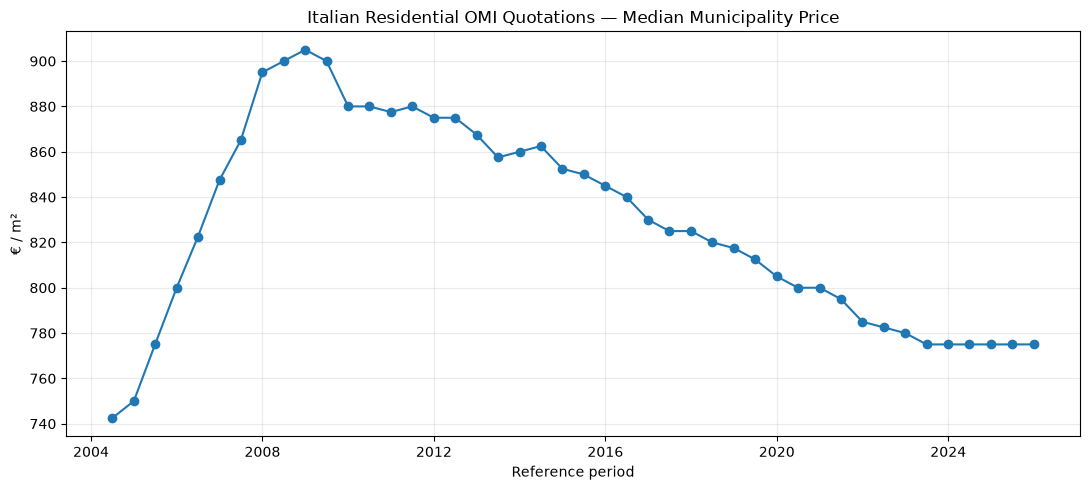

In [13]:
national_market = (
    market_panel.groupby(['reference_year', 'semester', 'reference_date'], as_index=False)
    .agg(
        median_price_m2=('median_price_m2', 'median'),
        total_ntn=('ntn', 'sum'),
        total_population=('population', 'sum'),
        municipalities_price=('median_price_m2', 'count'),
    )
)
national_market['price_change_pct'] = national_market['median_price_m2'].pct_change() * 100
national_market['ntn_change_pct'] = national_market['total_ntn'].pct_change() * 100
display(national_market.tail(12))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national_market['reference_date'], national_market['median_price_m2'], marker='o')
ax.set_title('Italian Residential OMI Quotations — Median Municipality Price')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 8. Population growth versus price appreciation

The first cross-sectional test asks whether municipalities with stronger population growth also exhibit stronger price appreciation. Only observations with valid changes and both measures available are used.

,relationship,pearson_corr,observations
0,population growth vs price growth,NaN,0
1,population growth vs NTN growth,NaN,0
2,price growth vs NTN growth,NaN,0


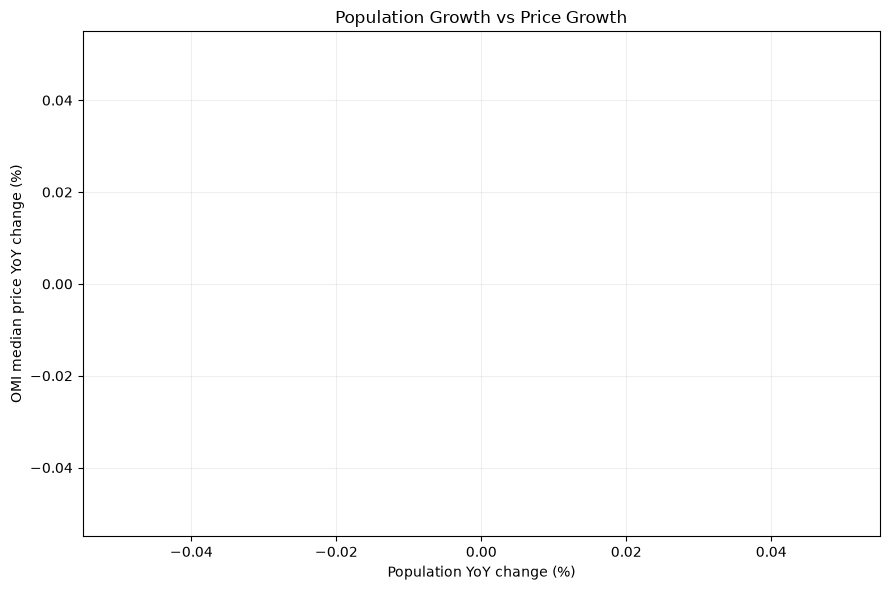

In [14]:
analysis = market_panel.dropna(
    subset=['price_yoy_pct', 'population_yoy_pct', 'ntn_yoy_pct']
).copy()
analysis = (
    analysis.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['price_yoy_pct', 'population_yoy_pct', 'ntn_yoy_pct'])
)

correlations = pd.DataFrame({
    'relationship': [
        'population growth vs price growth',
        'population growth vs NTN growth',
        'price growth vs NTN growth',
    ],
    'pearson_corr': [
        analysis['population_yoy_pct'].corr(analysis['price_yoy_pct']),
        analysis['population_yoy_pct'].corr(analysis['ntn_yoy_pct']),
        analysis['price_yoy_pct'].corr(analysis['ntn_yoy_pct']),
    ],
    'observations': [len(analysis)] * 3,
})
display(correlations)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(analysis['population_yoy_pct'], analysis['price_yoy_pct'], alpha=0.15)
ax.set_title('Population Growth vs Price Growth')
ax.set_xlabel('Population YoY change (%)')
ax.set_ylabel('OMI median price YoY change (%)')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 9. Market segmentation

National correlations can hide substantial heterogeneity. Municipalities are therefore grouped into population-growth and price-growth quadrants.

In [15]:
analysis['population_growth_group'] = np.where(
    analysis['population_yoy_pct'] >= 0,
    'Population growth',
    'Population decline',
)
analysis['price_growth_group'] = np.where(
    analysis['price_yoy_pct'] >= 0,
    'Price growth',
    'Price decline',
)
quadrants = (
    analysis.groupby(
        ['population_growth_group', 'price_growth_group'],
        as_index=False,
    )
    .agg(
        observations=('municipality_code', 'size'),
        municipalities=('municipality_code', 'nunique'),
        median_ntn_growth_pct=('ntn_yoy_pct', 'median'),
    )
    .sort_values('observations', ascending=False)
)
quadrants['share_pct'] = quadrants['observations'] / len(analysis) * 100
display(quadrants)

,population_growth_group,price_growth_group,observations,municipalities,median_ntn_growth_pct,share_pct


## 10. Largest markets and demographic context

A market-level view helps identify whether national patterns are driven by a small number of large municipalities.

In [16]:
latest_year = market_panel['reference_year'].max()
latest = market_panel.loc[market_panel['reference_year'].eq(latest_year)].copy()
latest_summary = (
    latest.groupby('municipality_code', as_index=False)
    .agg(
        population=('population', 'first'),
        ntn=('ntn', 'first'),
        median_price_m2=('median_price_m2', 'median'),
        price_yoy_pct=('price_yoy_pct', 'median'),
        population_yoy_pct=('population_yoy_pct', 'median'),
    )
    .sort_values('population', ascending=False)
)
display(latest_summary.head(20))

,municipality_code,population,ntn,median_price_m2,price_yoy_pct,population_yoy_pct
0,1001001.0,NaN,NaN,535.00,-2.73,NaN
1,1001002.0,NaN,NaN,835.00,0.00,NaN
2,1001003.0,NaN,NaN,555.00,-1.33,NaN
3,1001004.0,NaN,NaN,587.50,0.43,NaN
4,1001006.0,NaN,NaN,"1,005.00",0.75,NaN
5,1001007.0,NaN,NaN,415.00,-0.60,NaN
6,1001008.0,NaN,NaN,"1,302.50",1.26,NaN
7,1001009.0,NaN,NaN,948.75,1.20,NaN
8,1001010.0,NaN,NaN,442.50,0.00,NaN
9,1001011.0,NaN,NaN,612.50,-2.00,NaN


## 11. Analytical conclusions and limitations

### What this panel enables
- compare price levels and transaction intensity at municipality level;
- examine demographic expansion or contraction alongside market dynamics;
- segment municipalities into price/population growth regimes;
- identify candidates for deeper regional or municipality-level case studies.

### Interpretation limits
- OMI quotations are valuation ranges, not observed transaction prices;
- the municipality price indicator is a descriptive median of OMI quotation midpoints;
- NTN measures normalized transaction volumes and does not represent transaction value;
- population is annual while OMI quotations are semiannual;
- changes in OMI coverage, municipality boundaries, property mix and data availability can affect comparisons;
- correlations do not establish causal effects.

### Next analytical step

The next notebook should move from descriptive integration to a **regional/municipality panel analysis**, controlling at minimum for market size and geography and separating price level, price growth and transaction intensity.